In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


## Tuition Centre Student-Tutor Assignment Optimisation

### Problem Requirements
- Each student is assigned **exactly one tutor**
- Students requiring **extensive tutoring** can only be assigned to tutors with **extensive skill**
- The total number of students per tutor (existing active + newly assigned) cannot exceed their **maximum overall capacity**
- Tutors have indicated their **top 2 preferred centres**; assignments should maximise preference matching where possible

### Two Scenarios
**(a)** Minimise the number of tutors used, then maximise tutor centre preference  
**(b)** Balance tutor workload as evenly as possible, then maximise tutor centre preference

### Assumptions
- Only **active** existing students count towards a tutor's current load; inactive historical records are excluded
- **Preference scoring:** Pref1 (first choice centre) = **2**, pref2 (second choice) = **1**, no match = **0**. This weighted scheme is applied to both scenarios as it better reflects the true strength of a preference match and ensures that the models prioritize the preference of the tutors.
- Both scenarios assume that for each tutor, they either do not have any lessons that clash, or they can teach more than one student at the same time
- **Lexicographic optimisation is used for both scenarios:** The primary objective (minimising tutors used / balancing workload) is always solved first and fixed before optimising the secondary objective (maximising preference score). This ensures the primary objective is never compromised for a better preference match. 

In [3]:
import math
import pandas as pd
from docplex.mp.model import Model

## 1. Data Loading & Pre-processing

Reads the three sheets from the Excel file, counts active existing students per tutor, checks feasibility, and builds eligibility and preference score lookups for each (student, tutor) pair.

In [5]:
def load_data(excel_path: str):
    new_students = pd.read_excel(excel_path, sheet_name="New Students")
    tutors       = pd.read_excel(excel_path, sheet_name="Tutor Information")
    existing     = pd.read_excel(excel_path, sheet_name="Existing Students")

    # Standardise string columns
    for df in (new_students, tutors, existing):
        for c in df.columns:
            if df[c].dtype == "object":
                df[c] = df[c].astype(str).str.strip()

    # Count only ACTIVE existing students towards capacity.
    # Cast to string to safely handle both boolean True and string "True" from Excel.
    existing_active = existing[
        existing["active"].astype(str).str.strip().str.lower() == "true"
    ].copy()
    exist_count = (
        existing_active.groupby("tutorId")["studentId"]
        .nunique()
        .to_dict()
    )

    S = new_students["studentId"].tolist()
    T = tutors["tutorId"].tolist()

    need   = dict(zip(new_students["studentId"], new_students["tutoringNeed"]))
    centre = dict(zip(new_students["studentId"], new_students["tuitionCentre"]))
    skill  = dict(zip(tutors["tutorId"], tutors["tutoringSkills"]))
    pref1  = dict(zip(tutors["tutorId"], tutors["preferredCentre1"]))
    pref2  = dict(zip(tutors["tutorId"], tutors["preferredCentre2"]))
    cap    = dict(zip(tutors["tutorId"], tutors["maxOverallCapacity"]))

    # Check that capacity isn't already  exceeded
    for t in T:
        if exist_count.get(t, 0) > cap[t]:
            raise ValueError(
                f"Infeasible data: tutor {t} has existing_active={exist_count.get(t,0)} "
                f"> capacity={cap[t]}"
            )

    # Eligibility + preference score per (student, tutor) pair
    # 2 = pref1, 1 = pref2, 0 = no match
    eligible = {}
    score    = {}
    for s in S:
        for t in T:
            is_eligible = (
                need[s] == "Normal" or
                (need[s] == "Extensive" and skill[t] == "Extensive")
            )
            eligible[(s, t)] = int(is_eligible)

            if centre[s] == pref1[t]:
                score[(s, t)] = 2
            elif centre[s] == pref2[t]:
                score[(s, t)] = 1
            else:
                score[(s, t)] = 0

    return {
        "S": S, "T": T,
        "need": need, "centre": centre,
        "skill": skill, "pref1": pref1, "pref2": pref2,
        "cap": cap, "exist_count": exist_count,
        "eligible": eligible, "score": score,
    }

excel_path = "Interview small data.xlsx"
params = load_data(excel_path)
print(f"Loaded {len(params['S'])} new students and {len(params['T'])} tutors.")

Loaded 20 new students and 10 tutors.


## 2. Common Model Builder

Shared across both scenarios. Builds the base IP model with the following decision variables and constraints:

### Decision Variables
- $x_{s,t} \in \{0,1\}$ — equals 1 if student $s$ is assigned to tutor $t$
- $y_t \in \{0,1\}$ — equals 1 if tutor $t$ receives at least one new student

### Constraints
**(C1) Assignment:** Each student is assigned to exactly one tutor
$$\sum_{t} x_{s,t} = 1 \quad \forall s$$

**(C2) Capacity:** Existing active students + newly assigned cannot exceed max capacity
$$\text{exist\_count}_t + \sum_{s} x_{s,t} \leq \text{cap}_t \quad \forall t$$

**(C3) Linking:** $y_t = 1$ if and only if tutor $t$ receives any new students
$$\sum_{s} x_{s,t} \leq M \cdot y_t \quad \forall t$$
$$\sum_{s} x_{s,t} \geq y_t \quad \forall t$$

In [7]:
def build_common_assignment_model(params, model_name="assignment", cap_override=None):
    """
    Builds the base IP assignment model shared by both scenarios.
    cap_override: optional dict {tutorId: effective_capacity} used in Scenario (b)
                  to block saturated tutors from receiving new students.
    """
    S, T        = params["S"], params["T"]
    cap         = cap_override if cap_override is not None else params["cap"]
    exist_count = params["exist_count"]
    eligible    = params["eligible"]
    score       = params["score"]

    M = len(S)  # big-M for linking constraints
    mdl = Model(name=model_name)

    # Only create x variables for eligible (student, tutor) pairs
    eligible_pairs = [(s, t) for s in S for t in T if eligible[(s, t)] == 1]
    x = mdl.binary_var_dict(eligible_pairs, name="x")  # x[s,t] in {0,1}
    y = mdl.binary_var_dict(T, name="y")               # y[t] in {0,1}

    # Each student assigned to exactly one tutor
    for s in S:
        mdl.add_constraint(
            mdl.sum(x[(s, t)] for t in T if (s, t) in x) == 1,
            ctname=f"assign_{s}"
        )

    # Capacity: existing active + new assigned <= max capacity
    for t in T:
        mdl.add_constraint(
            exist_count.get(t, 0) + mdl.sum(x[(s, t)] for s in S if (s, t) in x) <= cap[t],
            ctname=f"cap_{t}"
        )

    # Link y[t] to whether tutor t receives any new students
    for t in T:
        new_load_t = mdl.sum(x[(s, t)] for s in S if (s, t) in x)
        mdl.add_constraint(new_load_t <= M * y[t], ctname=f"link_up_{t}")
        mdl.add_constraint(new_load_t >= y[t],     ctname=f"link_low_{t}")

    # Preference expression: weighted sum of scores across all assignments
    pref_expr = mdl.sum(score[(s, t)] * x[(s, t)] for (s, t) in x)

    return mdl, x, y, pref_expr, M


def extract_solution(params, x_sol):
    """Return a DataFrame mapping each student to their assigned tutor."""
    S, T = params["S"], params["T"]
    rows = []
    for s in S:
        chosen_t = None
        for t in T:
            if (s, t) in x_sol and x_sol[(s, t)].solution_value > 0.5:
                chosen_t = t
                break
        rows.append({"studentId": s, "assignedTutor": chosen_t})
    return pd.DataFrame(rows)

## 3. Scenario (a) — Minimise Tutors Used, then Maximise Preference

**Two-stage lexicographic approach:**

**Stage 1:** Minimise the number of tutors used
$$\min \sum_{t} y_t$$

**Stage 2:** Fix tutor count to the Stage 1 optimum $K^{*}$, then maximise total preference score
$$\max \sum_{s,t} \text{score}_{s,t} \cdot x_{s,t}$$
$$\text{subject to: } \sum_{t} y_t = K^{*}$$

This ensures the primary objective (fewest tutors) is never compromised when optimising the secondary objective (preference).

In [9]:
def solve_a(params, log_output=True):
    # Minimise number of tutors used
    mdl1, x1, y1, _, M = build_common_assignment_model(params, model_name="A_stage1")
    tutors_used_expr1 = mdl1.sum(y1[t] for t in params["T"])
    mdl1.minimize(tutors_used_expr1)

    sol1 = mdl1.solve(log_output=log_output)
    if sol1 is None:
        raise RuntimeError("Scenario (a) Stage 1 infeasible or no solution.")

    K_star = int(round(sol1.get_value(tutors_used_expr1)))
    print(f"Stage 1 complete -- minimum tutors required: {K_star}")

    # Fix tutor count to K_star, maximise preference score
    mdl2, x2, y2, pref2, M = build_common_assignment_model(params, model_name="A_stage2")
    tutors_used_expr2 = mdl2.sum(y2[t] for t in params["T"])
    mdl2.add_constraint(tutors_used_expr2 == K_star, ctname="fix_num_tutors")
    mdl2.maximize(pref2)

    sol2 = mdl2.solve(log_output=log_output)
    if sol2 is None:
        raise RuntimeError("Scenario (a) Stage 2 infeasible or no solution.")

    assign_df = extract_solution(params, x2)
    return K_star, sol2.objective_value, assign_df


K_star, pref_score_a, assign_a = solve_a(params, log_output=False)
print(f"\n=== Scenario (a) Results ===")
print(f"Tutors used      : {K_star}")
print(f"Preference score : {pref_score_a}")
display(assign_a)

-- cannot find parameters matching version: 22.1.2.0, using: 22.1.1.0
Stage 1 complete -- minimum tutors required: 4
-- cannot find parameters matching version: 22.1.2.0, using: 22.1.1.0

=== Scenario (a) Results ===
Tutors used      : 4
Preference score : 39.0


,studentId,assignedTutor
0,S0001,A001
1,S0002,A010
2,S0003,A009
3,S0004,A001
4,S0005,A009
5,S0006,A001
6,S0007,A001
7,S0008,A009
8,S0009,A002
9,S0010,A010


## 4. Scenario (b) — Balance Workload, then Maximise Preference

### Step 1: Pre-processing — Computing the Target Mean Load

Before optimising, we identified saturated tutors whose existing active load already meets or exceeds the mean. Assigning new students to them would only worsen the balance.

**Step 1:** Compute the initial mean target load
$$\mu = \frac{\text{total existing active} + \text{total new students}}{\text{number of tutors}}$$

**Step 2:** Identify tutors whose existing load $\geq \mu$ — mark as saturated

**Step 3:** Remove saturated tutors and recompute $\mu$ with remaining tutors

**Step 4:** Repeat until no new saturated tutors are found

In [11]:
def compute_mean_target(params):
    """
    Iteratively compute the converged target mean workload.
    Returns the mean, its ceiling, active tutors, saturated tutors,
    and effective capacities to pass to the optimisation model.
    """
    T           = params["T"]
    S           = params["S"]
    exist_count = params["exist_count"]
    cap         = params["cap"]

    total_new        = len(S)
    remaining_tutors = list(T)
    saturated        = []

    while True:
        total_existing = sum(exist_count.get(t, 0) for t in remaining_tutors)
        mean = (total_existing + total_new) / len(remaining_tutors)

        newly_saturated = [t for t in remaining_tutors if exist_count.get(t, 0) >= mean]

        if not newly_saturated:
            break

        saturated.extend(newly_saturated)
        remaining_tutors = [t for t in remaining_tutors if t not in newly_saturated]

        if not remaining_tutors:
            raise RuntimeError(
                "All tutors are already at or above the computed mean. "
                "No tutor can accept new students."
            )

    for t in remaining_tutors:
        if cap[t] - exist_count.get(t, 0) <= 0:
            raise RuntimeError(f"Tutor {t} has no remaining capacity despite being below mean.")

    mean_ceil = math.ceil(mean)

    # Saturated tutors: cap = existing load (blocks any new assignment)
    # Active tutors: retain real cap; balance enforced via the objective
    effective_cap = {
        t: (exist_count.get(t, 0) if t in saturated else cap[t])
        for t in T
    }

    print(f"[Workload Balance Pre-processing]")
    print(f"  Total new students : {total_new}")
    print(f"  Saturated tutors   : {saturated} (existing load >= mean, receive no new students)")
    print(f"  Active tutors      : {remaining_tutors}")
    print(f"  Converged mean     : {mean:.2f}  (ceiling = {mean_ceil})")

    return mean, mean_ceil, remaining_tutors, saturated, effective_cap

### Step 2: Optimisation — Minimise Max Load, then Maximise Preference

**Two-stage lexicographic approach:**

**Stage 1:** Among active tutors, minimise the maximum total load
$$\min \ L_{\max}$$
$$\text{subject to: } \text{exist\_count}_t + \sum_{s} x_{s,t} \leq L_{\max} \quad \forall t \in \text{active tutors}$$

This pushes all active tutors toward the mean $\mu$, with any remainder spread naturally by the min-max objective.

**Stage 2:** Fix the optimal max load $L_{\max}^{*}$ from Stage 1, then maximise total preference score
$$\max \sum_{s,t} \text{score}_{s,t} \cdot x_{s,t}$$
$$\text{subject to: } L_{\max} = L_{\max}^{*}$$

This ensures the primary objective (balanced workload) is never compromised when optimising the secondary objective (preference).

In [13]:
def solve_b(params, log_output=True):
    S, T        = params["S"], params["T"]
    exist_count = params["exist_count"]

    mean, mean_ceil, active_tutors, saturated_tutors, effective_cap = compute_mean_target(params)

    params_b        = dict(params)
    params_b["cap"] = effective_cap

    # Minimise max TOTAL load (existing + new) among active tutors
    mdl1, x1, y1, _, M = build_common_assignment_model(
        params_b, model_name="B_stage1", cap_override=effective_cap
    )
    Lmax1 = mdl1.integer_var(lb=0, name="Lmax")

    for t in active_tutors:
        total_load_t = exist_count.get(t, 0) + mdl1.sum(x1[(s, t)] for s in S if (s, t) in x1)
        mdl1.add_constraint(total_load_t <= Lmax1, ctname=f"def_Lmax_{t}")

    for t in saturated_tutors:
        mdl1.add_constraint(
            mdl1.sum(x1[(s, t)] for s in S if (s, t) in x1) == 0,
            ctname=f"saturated_{t}"
        )

    mdl1.minimize(Lmax1)
    sol1 = mdl1.solve(log_output=log_output)
    if sol1 is None:
        raise RuntimeError("Scenario (b) Stage 1 infeasible or no solution.")

    Lmax_star = int(round(sol1.objective_value))
    print(f"Stage 1 complete -- optimal max total load: {Lmax_star}  (target mean: {mean:.2f})")

    # Fix Lmax, maximise preference score
    mdl2, x2, y2, pref_expr2, M = build_common_assignment_model(
        params_b, model_name="B_stage2", cap_override=effective_cap
    )
    Lmax2 = mdl2.integer_var(lb=0, name="Lmax")

    for t in active_tutors:
        total_load_t = exist_count.get(t, 0) + mdl2.sum(x2[(s, t)] for s in S if (s, t) in x2)
        mdl2.add_constraint(total_load_t <= Lmax2, ctname=f"def_Lmax_{t}")

    for t in saturated_tutors:
        mdl2.add_constraint(
            mdl2.sum(x2[(s, t)] for s in S if (s, t) in x2) == 0,
            ctname=f"saturated_{t}"
        )

    mdl2.add_constraint(Lmax2 == Lmax_star, ctname="fix_max_load")
    mdl2.maximize(pref_expr2)

    sol2 = mdl2.solve(log_output=log_output)
    if sol2 is None:
        raise RuntimeError("Scenario (b) Stage 2 infeasible or no solution.")

    assign_df = extract_solution(params_b, x2)
    return Lmax_star, mean, sol2.objective_value, assign_df


Lmax_star, mean_target, pref_score_b, assign_b = solve_b(params, log_output=False)
print(f"\n=== Scenario (b) Results ===")
print(f"Target mean total load          : {round(mean_target, 2)}")
print(f"Optimal max total load (active) : {Lmax_star}")
print(f"Preference score                : {pref_score_b}")
display(assign_b)

[Workload Balance Pre-processing]
  Total new students : 20
  Saturated tutors   : ['A005', 'A007'] (existing load >= mean, receive no new students)
  Active tutors      : ['A001', 'A002', 'A003', 'A004', 'A006', 'A008', 'A009', 'A010']
  Converged mean     : 2.88  (ceiling = 3)
-- cannot find parameters matching version: 22.1.2.0, using: 22.1.1.0
Stage 1 complete -- optimal max total load: 3  (target mean: 2.88)
-- cannot find parameters matching version: 22.1.2.0, using: 22.1.1.0

=== Scenario (b) Results ===
Target mean total load          : 2.88
Optimal max total load (active) : 3
Preference score                : 35.0


,studentId,assignedTutor
0,S0001,A001
1,S0002,A003
2,S0003,A009
3,S0004,A006
4,S0005,A009
5,S0006,A001
6,S0007,A006
7,S0008,A008
8,S0009,A004
9,S0010,A008


## 5. Export Results to Excel

In [15]:
#Exports the assignment results for both scenarios to an Excel file with separate sheets.
output_path = "Assignment Results.xlsx"

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    assign_a.to_excel(writer, sheet_name="Scenario A", index=False)
    assign_b.to_excel(writer, sheet_name="Scenario B", index=False)

## 6. Visualisations

Three charts summarising the optimisation results:
- **Tutor Workload** — existing vs. newly assigned students per tutor, with capacity limits
- **Preference Match Breakdown** — how many students received a first-choice, second-choice, or no match
- **Assignment Heatmap** — student × tutor assignment matrix for each scenario

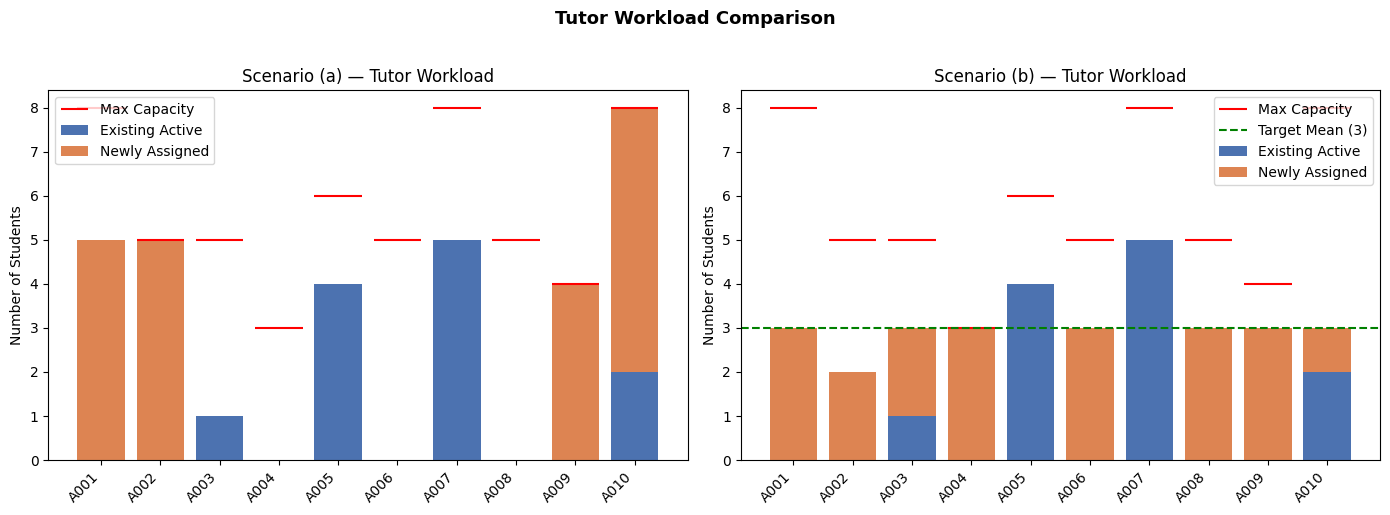

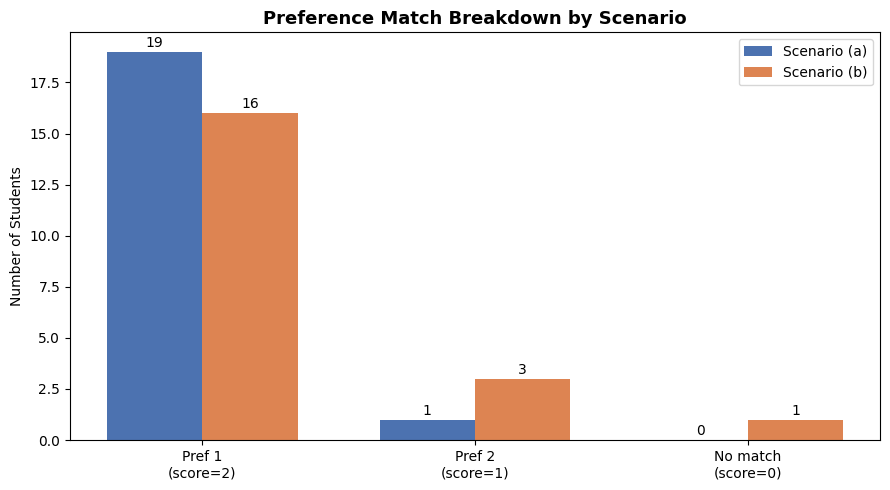

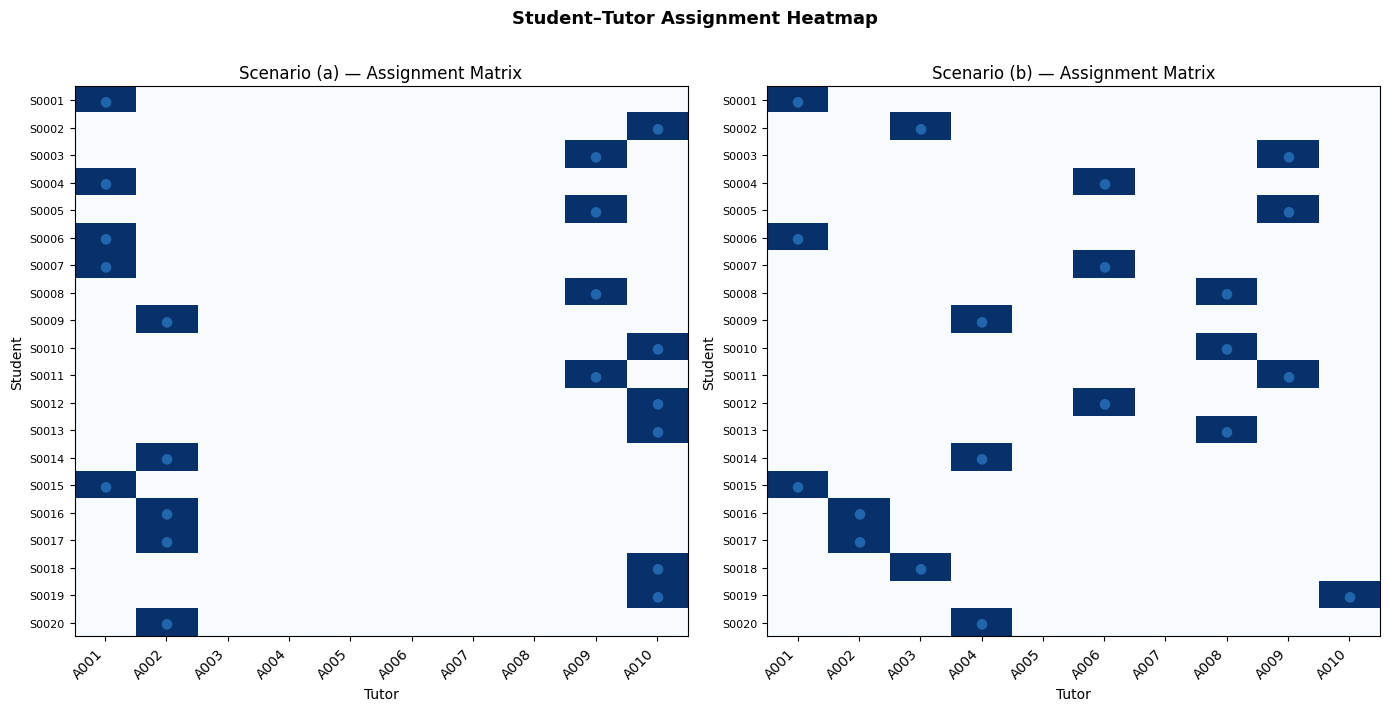

In [33]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd


# Tutor Workload Comparison 
def plot_workload(params, assign_a, assign_b):
    T = params["T"]
    exist_count = params["exist_count"]
    cap = params["cap"]

    new_a = assign_a.groupby("assignedTutor").size().reindex(T, fill_value=0)
    new_b = assign_b.groupby("assignedTutor").size().reindex(T, fill_value=0)
    existing = pd.Series({t: exist_count.get(t, 0) for t in T})
    capacity = pd.Series({t: cap[t] for t in T})

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

    for ax, new_assign, title in zip(axes, [new_a, new_b], ["Scenario (a)", "Scenario (b)"]):
        x = list(range(len(T)))
        ax.bar(x, existing[T], label="Existing Active", color="#4C72B0")
        ax.bar(x, new_assign[T], bottom=existing[T], label="Newly Assigned", color="#DD8452")
        cap_vals = [capacity[t] for t in T]
        for i, (xi, cv) in enumerate(zip(x, cap_vals)):
            ax.hlines(cv, xi - 0.4, xi + 0.4, colors="red", linewidths=1.5,
                      label="Max Capacity" if i == 0 else "")
        # adding the optimal mean line for Scenario (b)
        if title == "Scenario (b)":
            ax.axhline(y=math.ceil(mean_target), color="green", linestyle="--", linewidth=1.5,
                   label=f"Target Mean ({math.ceil(mean_target)})")
        
        ax.set_xticks(x)
        ax.set_xticklabels(T, rotation=45, ha="right")
        ax.set_ylabel("Number of Students")
        ax.set_title(title + " — Tutor Workload")
        ax.legend()

    plt.suptitle("Tutor Workload Comparison", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


# Preference Score Breakdown 
def plot_preference_breakdown(params, assign_a, assign_b):
    score = params["score"]

    def get_pref_counts(assign_df):
        counts = {"Pref 1\n(score=2)": 0, "Pref 2\n(score=1)": 0, "No match\n(score=0)": 0}
        for _, row in assign_df.iterrows():
            s, t = row["studentId"], row["assignedTutor"]
            v = score.get((s, t), 0)
            if v == 2:   counts["Pref 1\n(score=2)"] += 1
            elif v == 1: counts["Pref 2\n(score=1)"] += 1
            else:        counts["No match\n(score=0)"] += 1
        return counts

    counts_a = get_pref_counts(assign_a)
    counts_b = get_pref_counts(assign_b)

    labels = list(counts_a.keys())
    vals_a = [counts_a[l] for l in labels]
    vals_b = [counts_b[l] for l in labels]

    x = list(range(len(labels)))
    width = 0.35

    fig, ax = plt.subplots(figsize=(9, 5))
    bars_a = ax.bar([i - width/2 for i in x], vals_a, width, label="Scenario (a)", color="#4C72B0")
    bars_b = ax.bar([i + width/2 for i in x], vals_b, width, label="Scenario (b)", color="#DD8452")

    for bar in list(bars_a) + list(bars_b):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.1, str(int(h)),
                ha="center", va="bottom", fontsize=10)

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("Number of Students")
    ax.set_title("Preference Match Breakdown by Scenario", fontsize=13, fontweight="bold")
    ax.legend()
    plt.tight_layout()
    plt.show()


# Assignment Heatmap
def plot_assignment_heatmap(params, assign_a, assign_b):
    S, T = params["S"], params["T"]

    def to_matrix(assign_df):
        mat = pd.DataFrame(0, index=S, columns=T)
        for _, row in assign_df.iterrows():
            mat.loc[row["studentId"], row["assignedTutor"]] = 1
        return mat

    mat_a = to_matrix(assign_a)
    mat_b = to_matrix(assign_b)

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    for ax, mat, title in zip(axes, [mat_a, mat_b], ["Scenario (a)", "Scenario (b)"]):
        ax.imshow(mat.values, aspect="auto", cmap="Blues", vmin=0, vmax=1)
        ax.set_xticks(range(len(T)))
        ax.set_xticklabels(T, rotation=45, ha="right")
        ax.set_yticks(range(len(S)))
        ax.set_yticklabels(S, fontsize=8)
        ax.set_title(title + " — Assignment Matrix", fontsize=12)
        ax.set_xlabel("Tutor")
        ax.set_ylabel("Student")
        for si, s in enumerate(S):
            for ti, t in enumerate(T):
                if mat.loc[s, t] == 1:
                    ax.text(ti, si, "●", ha="center", va="center",
                            color="#2166ac", fontsize=10)

    plt.suptitle("Student–Tutor Assignment Heatmap", fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


plot_workload(params, assign_a, assign_b)
plot_preference_breakdown(params, assign_a, assign_b)
plot_assignment_heatmap(params, assign_a, assign_b)

## 7. Alternative Scenario (b) — Maximise Preference First, then Balance Workload

### Motivation
From the visualisations above, Scenario (b) results in one tutor being assigned a student outside their top 2 preferred centres (no match, score = 0). Since the problem statement does not explicitly specify which objective takes priority, this raises the question of whether preference satisfaction should instead be the primary objective, with workload balance as secondary.

This alternative formulation prioritises **maximising tutor preference first**, then minimises the maximum total load among active tutors — accepting that one or two tutors may end up with slightly more students, as long as all tutors are assigned students within their preferred centres where possible.

**Two-stage lexicographic approach:**

**Stage 1:** Maximise total preference score
$$\max \sum_{s,t} \text{score}_{s,t} \cdot x_{s,t}$$

**Stage 2:** Fix preference score to the Stage 1 optimum $P^{*}$, then minimise the maximum total load
$$\min \ L_{\max}$$
$$\text{subject to: } \sum_{s,t} \text{score}_{s,t} \cdot x_{s,t} = P^{*}$$
$$\text{and: } \text{exist\_count}_t + \sum_{s} x_{s,t} \leq L_{\max} \quad \forall t \in \text{active tutors}$$

In [35]:
def solve_b_alt(params, log_output=True):
    S, T        = params["S"], params["T"]
    exist_count = params["exist_count"]

    mean, mean_ceil, active_tutors, saturated_tutors, effective_cap = compute_mean_target(params)

    params_b        = dict(params)
    params_b["cap"] = effective_cap

    # Maximise preference score
    mdl1, x1, y1, pref_expr1, M = build_common_assignment_model(
        params_b, model_name="B_alt_stage1", cap_override=effective_cap
    )

    for t in saturated_tutors:
        mdl1.add_constraint(
            mdl1.sum(x1[(s, t)] for s in S if (s, t) in x1) == 0,
            ctname=f"saturated_{t}"
        )

    mdl1.maximize(pref_expr1)
    sol1 = mdl1.solve(log_output=log_output)
    if sol1 is None:
        raise RuntimeError("Alternative Scenario (b) Stage 1 infeasible or no solution.")

    P_star = sol1.objective_value
    print(f"Stage 1 complete -- optimal preference score: {P_star}")

    # Fix preference score, minimise max total load
    mdl2, x2, y2, pref_expr2, M = build_common_assignment_model(
        params_b, model_name="B_alt_stage2", cap_override=effective_cap
    )
    Lmax2 = mdl2.integer_var(lb=0, name="Lmax")

    for t in active_tutors:
        total_load_t = exist_count.get(t, 0) + mdl2.sum(x2[(s, t)] for s in S if (s, t) in x2)
        mdl2.add_constraint(total_load_t <= Lmax2, ctname=f"def_Lmax_{t}")

    for t in saturated_tutors:
        mdl2.add_constraint(
            mdl2.sum(x2[(s, t)] for s in S if (s, t) in x2) == 0,
            ctname=f"saturated_{t}"
        )

    mdl2.add_constraint(pref_expr2 == P_star, ctname="fix_pref_score")
    mdl2.minimize(Lmax2)

    sol2 = mdl2.solve(log_output=log_output)
    if sol2 is None:
        raise RuntimeError("Alternative Scenario (b) Stage 2 infeasible or no solution.")

    assign_df = extract_solution(params_b, x2)
    return P_star, int(round(sol2.objective_value)), mean, assign_df


P_star_alt, Lmax_alt, mean_alt, assign_b_alt = solve_b_alt(params, log_output=False)
print(f"\n=== Alternative Scenario (b) Results ===")
print(f"Optimal preference score        : {P_star_alt}")
print(f"Resulting max total load        : {Lmax_alt}")
print(f"Target mean total load          : {round(mean_alt, 2)}")
display(assign_b_alt)

[Workload Balance Pre-processing]
  Total new students : 20
  Saturated tutors   : ['A005', 'A007'] (existing load >= mean, receive no new students)
  Active tutors      : ['A001', 'A002', 'A003', 'A004', 'A006', 'A008', 'A009', 'A010']
  Converged mean     : 2.88  (ceiling = 3)
-- cannot find parameters matching version: 22.1.2.0, using: 22.1.1.0
Stage 1 complete -- optimal preference score: 39.0
-- cannot find parameters matching version: 22.1.2.0, using: 22.1.1.0

=== Alternative Scenario (b) Results ===
Optimal preference score        : 39.0
Resulting max total load        : 5
Target mean total load          : 2.88


,studentId,assignedTutor
0,S0001,A006
1,S0002,A003
2,S0003,A008
3,S0004,A006
4,S0005,A008
5,S0006,A009
6,S0007,A006
7,S0008,A008
8,S0009,A002
9,S0010,A010


## 8. Comparison of the original Scenario (b) vs Alternative Scenario (b)

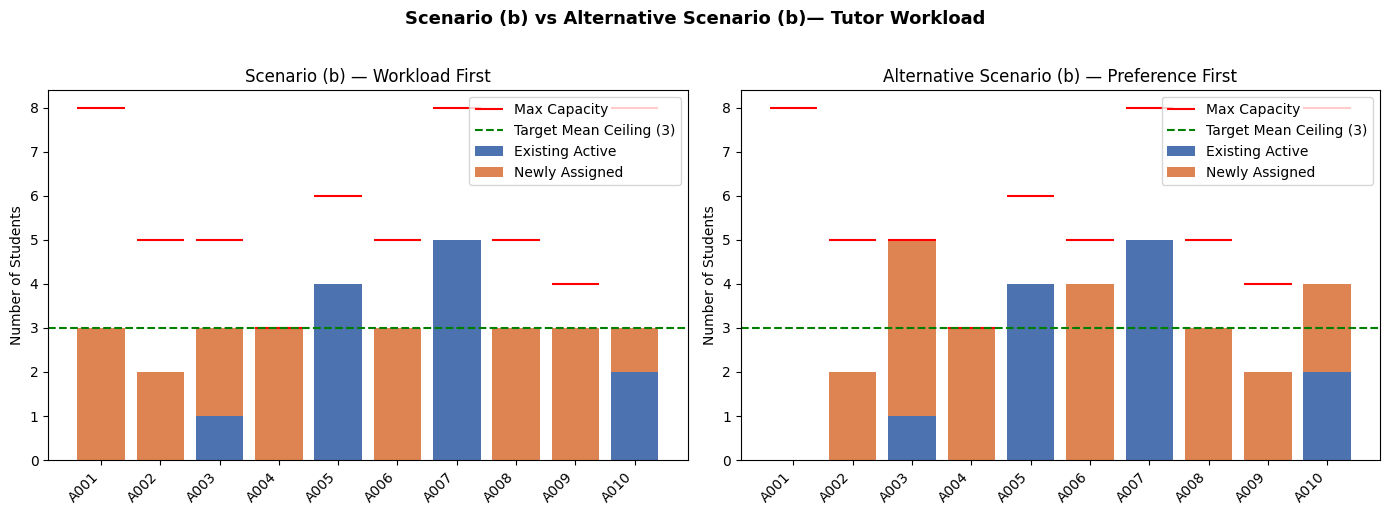

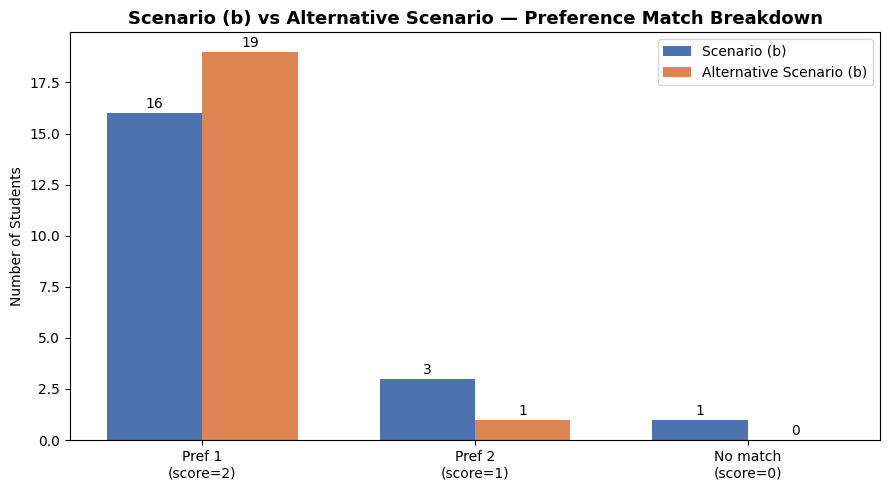

In [38]:
def plot_workload_b_comparison(params, assign_b, assign_b_alt):
    T = params["T"]
    exist_count = params["exist_count"]
    cap = params["cap"]

    new_b     = assign_b.groupby("assignedTutor").size().reindex(T, fill_value=0)
    new_b_alt = assign_b_alt.groupby("assignedTutor").size().reindex(T, fill_value=0)
    existing  = pd.Series({t: exist_count.get(t, 0) for t in T})
    capacity  = pd.Series({t: cap[t] for t in T})

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

    for ax, new_assign, title in zip(
        axes, [new_b, new_b_alt],
        ["Scenario (b) — Workload First", "Alternative Scenario (b) — Preference First"]
    ):
        x = list(range(len(T)))
        ax.bar(x, existing[T], label="Existing Active", color="#4C72B0")
        ax.bar(x, new_assign[T], bottom=existing[T], label="Newly Assigned", color="#DD8452")
        for i, (xi, cv) in enumerate(zip(x, [capacity[t] for t in T])):
            ax.hlines(cv, xi - 0.4, xi + 0.4, colors="red", linewidths=1.5,
                      label="Max Capacity" if i == 0 else "")
        # Adding the mean ceiling line for both Scenario (b) plots
        ax.axhline(y=math.ceil(mean_alt), color="green", linestyle="--", linewidth=1.5,
               label=f"Target Mean Ceiling ({math.ceil(mean_alt)})")
        
        ax.set_xticks(x)
        ax.set_xticklabels(T, rotation=45, ha="right")
        ax.set_ylabel("Number of Students")
        ax.set_title(title)
        ax.legend()

    plt.suptitle("Scenario (b) vs Alternative Scenario (b)— Tutor Workload", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


def plot_pref_b_comparison(params, assign_b, assign_b_alt):
    score = params["score"]

    def get_pref_counts(assign_df):
        counts = {"Pref 1\n(score=2)": 0, "Pref 2\n(score=1)": 0, "No match\n(score=0)": 0}
        for _, row in assign_df.iterrows():
            s, t = row["studentId"], row["assignedTutor"]
            v = score.get((s, t), 0)
            if v == 2:   counts["Pref 1\n(score=2)"] += 1
            elif v == 1: counts["Pref 2\n(score=1)"] += 1
            else:        counts["No match\n(score=0)"] += 1
        return counts

    counts_b     = get_pref_counts(assign_b)
    counts_b_alt = get_pref_counts(assign_b_alt)

    labels = list(counts_b.keys())
    vals_b     = [counts_b[l] for l in labels]
    vals_b_alt = [counts_b_alt[l] for l in labels]

    x = list(range(len(labels)))
    width = 0.35

    fig, ax = plt.subplots(figsize=(9, 5))
    bars_b     = ax.bar([i - width/2 for i in x], vals_b,     width, label="Scenario (b)", color="#4C72B0")
    bars_b_alt = ax.bar([i + width/2 for i in x], vals_b_alt, width, label="Alternative Scenario (b)", color="#DD8452")

    for bar in list(bars_b) + list(bars_b_alt):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.1, str(int(h)),
                ha="center", va="bottom", fontsize=10)

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("Number of Students")
    ax.set_title("Scenario (b) vs Alternative Scenario — Preference Match Breakdown", fontsize=13, fontweight="bold")
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_workload_b_comparison(params, assign_b, assign_b_alt)
plot_pref_b_comparison(params, assign_b, assign_b_alt)